# Analytic disk

We create a Magritte model from an analytic description of a Keplerian disk (see e.g. [Homan et al. 2018](https://doi.org/10.1051/0004-6361/201732246); [Booth et al. 2019](https://doi.org/10.1051/0004-6361/201834388)).

## Setup

Import the required functionalty.

In [1]:
import matplotlib.pyplot as plt                   # Plotting
import magritte.setup    as setup                   # Model setup
import magritte.core     as magritte                # Core functionality
import magritte.plot     as plot                       # Plotting
import magritte.mesher   as mesher                  # Mesher

import numpy             as np                      # Data structures
import warnings                                     # Hide warnings
warnings.filterwarnings('ignore')                   # especially for yt
import yt                                           # 3D plotting
import os

from tqdm                import tqdm                # Progress bars
from astropy             import units, constants    # Unit conversions
from scipy.spatial       import Delaunay, cKDTree   # Finding neighbors
from yt.funcs            import mylog               # To avoid yt output 
mylog.setLevel(40)                                  # as error messages

Define a working directory (you will have to change this; it must be an **absolute path**).

In [2]:
wdir = "/home/yasho379/magritte_rebuilt/tgs/"

Define file names.

In [3]:
model_file = os.path.join(wdir, 'model_analytic_sphere_nh3.hdf5')   # Resulting Magritte model
lamda_file = os.path.join(wdir, 'p-nh3@loreau.dat.txt'                  )   # Line data file
bmesh_name = os.path.join(wdir, 'analytic_disk'           )   # bachground mesh name (no extension!)

## Model parameters

The functions below describe the disk structure, based on the Magritte application presented in [De Ceuster et al. (2019)](https://doi.org/10.1093/mnras/stz3557).

In [4]:
G      =           constants.G.si.value
kb     =           constants.k_B.si.value
m_H2   = 2.01588 * constants.u.si.value


XNH3    =  1e-8   # [.]
vturb  =  300    # [m/s]

T_cloud =  35 # [K]

rho_cloud = 1.0E6 * 1.0E6 * m_H2   # [kg/m^3]
r_out  =   5000.0 * constants.au.si.value
r_in   =    100.0 * constants.au.si.value


def density(rr):
    rho_0 = rho_cloud  # central density in si units
    r_0 = r_in # inner flat part radius in AU
    alpha = 2  # power-law index
    r_max = r_out  # outer cutoff radius in AU

    # Compute radial distance
    Radius = (rr[0]**2. + rr[1]**2. + rr[2]**2.)**0.5

    # Calculate density profile
    GasDensity = rho_0 / (1.0 + (Radius / r_0)**alpha)

    # Apply cutoff beyond r_out
    if hasattr(Radius, "__len__"):
        GasDensity[Radius > r_max] = 0.0
    else:
        if Radius > r_max:
            GasDensity = 0.0

    return GasDensity

def abn_nH2(rr):
    """
    H2 number density function.
    """
    return density(rr) / (2.01588 * constants.u.si.value)

def abn_nNH3(rr):
    """
    NH3 number density function.
    """
    return XNH3 * abn_nH2(rr)


def temperature(rr):
    return T_cloud
    
        
def turbulence(rr):
    """
    !!! Peculiar Magritte thing...
    Square turbulent speed as fraction of the speed of light.
    """
    return (vturb/constants.c.si.value)**2


def velocity_f(rr):
    """
    Inward radial velocity.
    """
    x, y, z = rr[0], rr[1], rr[2]
    r = np.sqrt(x**2 + y**2 + z**2)
    v_radial = 100   # [m/s], inward radial velocity
    if hasattr(r, "__len__"):
        v = np.zeros((3,) + r.shape)
        v[0] = v_radial * (x / r)
        v[1] = v_radial * (y / r)
        v[2] = v_radial * (z / r)
    else:
        v = np.array([v_radial * (x / r), v_radial * (y / r), v_radial * (z / r)])
    return v/ (3e8)

## Create background mesh

Define the desired background mesh, a ($75 \times 75 \times 75$) cube.

In [5]:
resolution = 75

xs = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)
ys = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)
zs = np.linspace(-r_out*1.2, +r_out*1.2, resolution, endpoint=True)

(Xs, Ys, Zs) = np.meshgrid(xs, ys, zs)

# Extract positions of points in background mesh
position = np.array((Xs.ravel(), Ys.ravel(), Zs.ravel())).T

# Evaluate the density on the cube
rhos      = density([Xs, Ys, Zs])
rhos_min  = np.min(rhos[rhos!=0.0])
rhos     += rhos_min

Now we remesh this model using the new remesher

In [6]:
positions_reduced, nb_boundary = mesher.remesh_point_cloud(position, rhos.ravel(), max_depth=10, threshold= 2e-1, hullorder=4)

new interior points:  27925
number boundary points:  1538


We add a spherical inner boundary at 0.01*r_out

In [7]:
healpy_order = 5 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(positions_reduced, nb_boundary, 0.01*r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))
print("number of boundary points: ", nb_boundary)

number of points in reduced grid:  29762
number of boundary points:  1838


We add a spherical outer boundary at r_out

In [8]:
healpy_order = 15 #using healpy to determine where to place the 12*healpy_order**2 boundary points on the sphere
origin = np.array([0.0,0.0,0.0]).T #the origin of the inner boundary sphere
positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(positions_reduced, nb_boundary, r_out, healpy_order=healpy_order, origin=origin)
print("number of points in reduced grid: ", len(positions_reduced))

number of points in reduced grid:  17645


In [9]:
npoints = len(positions_reduced)

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(positions_reduced)
(indptr, indices) = delaunay.vertex_neighbor_vertices
neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(npoints)]
nbs       = [n for sublist in neighbors for n in sublist]
n_nbs     = [len(sublist) for sublist in neighbors]

# Convenience arrays
zeros = np.zeros(npoints)
ones  = np.ones (npoints)

Convert model functions to arrays based the model mesh.

In [10]:
position = positions_reduced
velocity = np.array([velocity_f (rr) for rr in positions_reduced])
nH2      = np.array([abn_nH2    (rr) for rr in positions_reduced])
nNH3      = np.array([abn_nNH3   (rr) for rr in positions_reduced])
tmp      = np.array([temperature(rr) for rr in positions_reduced])
trb      = np.array([turbulence (rr) for rr in positions_reduced])

## Create model

Now all data is read, we can use it to construct a Magritte model.

<div class="alert alert-warning">

Warning

Since we do not aim to do self-consistent non-LTE simulations in these examples, we only consider the first radiative transition of CO (J=1-0). To consider all transitions, use `setup.set_linedata_from_LAMDA_file` as in the commented line below it.
We also only consider 2 rays here (up and down the direction we want to image). To consider all directions, comment out the indecated lines and use `setup.set_uniform_rays` as in the commented line below.
    
</div>

In [11]:
model = magritte.Model ()                              # Create model object

model.parameters.set_model_name         (model_file)   # Magritte model file
model.parameters.set_dimension          (3)            # This is a 3D model
model.parameters.set_npoints            (npoints)      # Number of points
model.parameters.set_nrays              (12*2*2)            # Number of rays  
model.parameters.set_nspecs             (3)            # Number of species (min. 5)
model.parameters.set_nlspecs            (1)            # Number of line species
model.parameters.set_nquads             (51)           # Number of quadrature points
model.parameters.sum_opacity_emissivity_over_all_lines = True
# model.parameters.one_line_approximation = False

model.geometry.points.position.set(position)
model.geometry.points.velocity.set(velocity)

model.geometry.points.  neighbors.set(  nbs)
model.geometry.points.n_neighbors.set(n_nbs)

model.chemistry.species.abundance = np.array((nNH3, nH2, zeros)).T
model.chemistry.species.symbol    = ['p-NH3', 'H2', 'e-']

model.thermodynamics.temperature.gas  .set(tmp)
model.thermodynamics.turbulence.vturb2.set(trb)

model.parameters.set_nboundary(nb_boundary)
model.geometry.boundary.boundary2point.set(np.arange(nb_boundary))

# direction = np.array([[+1,0,0], [-1,0,0]])            # Comment out to use all directions
# model.geometry.rays.direction.set(direction)          # Comment out to use all directions
# model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

setup.set_uniform_rays            (model)   # Uncomment to use all directions

setup.set_boundary_condition_CMB  (model)
#setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [0,1]})  # Consider only CO lines
setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
setup.set_quadrature              (model)

model.write()

[1, 2, 1, 6.23e-12, 6.03e-12, 5.45e-12, 4.69e-12, 4.07e-12, 3.58e-12, 3.21e-12, 2.91e-12, 2.68e-12, 2.49e-12, 2.33e-12]
[2, 3, 1, 5.83e-12, 6.42e-12, 6.2e-12, 5.3e-12, 4.48e-12, 3.84e-12, 3.33e-12, 2.93e-12, 2.6e-12, 2.34e-12, 2.11e-12]
[3, 3, 2, 3.06e-11, 3.06e-11, 2.82e-11, 2.42e-11, 2.09e-11, 1.82e-11, 1.62e-11, 1.46e-11, 1.33e-11, 1.23e-11, 1.14e-11]
[4, 4, 2, 9.38e-12, 1.27e-11, 1.3e-11, 1.12e-11, 9.38e-12, 7.92e-12, 6.77e-12, 5.86e-12, 5.14e-12, 4.54e-12, 4.06e-12]
[5, 4, 3, 5.92e-11, 7.03e-11, 8.64e-11, 9.14e-11, 9.3e-11, 9.38e-11, 9.44e-11, 9.52e-11, 9.6e-11, 9.7e-11, 9.8e-11]
[6, 5, 1, 1.88e-12, 2.55e-12, 2.61e-12, 2.24e-12, 1.88e-12, 1.58e-12, 1.35e-12, 1.17e-12, 1.03e-12, 9.09e-13, 8.11e-13]
[7, 5, 2, 4.77e-11, 5.72e-11, 6.93e-11, 7.24e-11, 7.3e-11, 7.31e-11, 7.32e-11, 7.34e-11, 7.38e-11, 7.43e-11, 7.49e-11]
[8, 5, 3, 1.9e-11, 2.33e-11, 2.75e-11, 2.79e-11, 2.75e-11, 2.7e-11, 2.67e-11, 2.64e-11, 2.63e-11, 2.63e-11, 2.63e-11]
[9, 5, 4, 5.13e-12, 5.66e-12, 5.22e-12, 4.5e-12, 3.

In [12]:
ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nNH3[delaunay.simplices].astype(np.float64)}
)


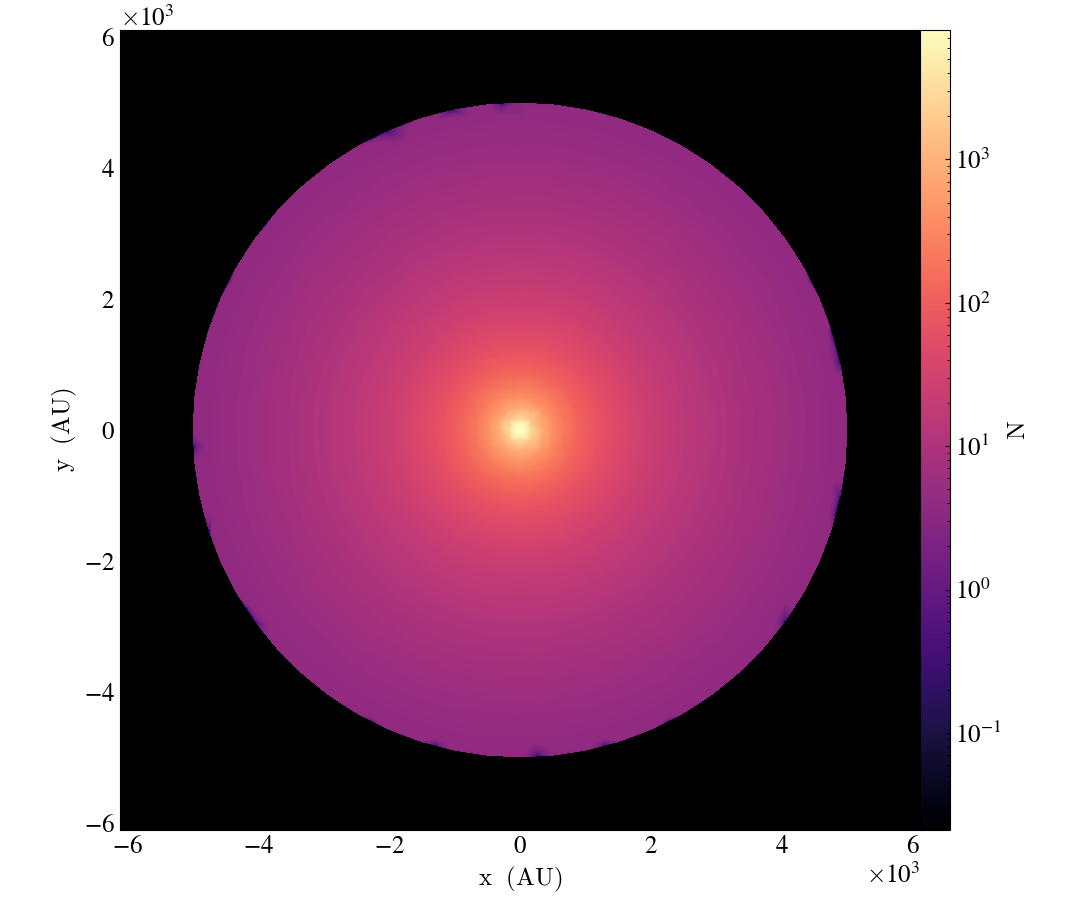

In [13]:
sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.zoom           (0.9)

In [14]:
model_file = os.path.join(wdir, 'model_analytic_sphere_nh3.hdf5')   # Resulting Magritte model

In [15]:
model = magritte.Model(model_file)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /home/yasho379/magritte_rebuilt/tgs/model_analytic_sphere_nh3.hdf5
-------------------------------------------
Reading parameters...
Reading points...
Reading rays...
Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 0
read sym p-NH3
nlev = 48
nrad = 115
Reading collisionPartner...
Reading quadrature...
Reading radiation...
Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 17645
  nrays      = 48
  nboundary  = 3000
  nfreqs     = 5865
  nspecs     = 3
  nlspec

In [ ]:
model.compute_spectral_discretisation ()
model.compute_inverse_line_widths     ()
model.compute_LTE_level_populations   ()
model.compute_level_populations_sparse (True, 10)#with param args: whether to use Ng-acceleration for faster convergence (True) and max number of NLTE iterations (20)

NameError: name 'model' is not defined

In [ ]:
fcen = model.lines.lineProducingSpecies[0].linedata.frequency
print(fcen)

[23692957706.689507, 23694486648.225372, 23693887063.30931, 23696045569.00709, 23695086233.141506, 23694486648.225445, 23722637160.031555, 23720598571.317253, 23722637160.03127, 23721348052.462082, 23724675748.74614, 23723926267.601025, 23722637160.031837, 1168452017500.4712, 1168451417915.555, 1168452677043.879, 1168453936172.2026, 1168453006815.5828, 1168452407230.6665, 1215245303182.8762, 1215244703597.9602, 23098799034.179657, 23098139490.77189, 23097809719.068005, 1215245992705.5295, 23099488556.832924, 23098829013.425156, 1215247281813.0989, 1215246322477.2334, 1215245722892.3174, 23099818328.536808, 23098829013.425156, 1763824129963.672, 1763823380482.5273, 1763822091374.9575, 1763823380482.5273, 1763822091374.9575, 1763823410461.773, 1810380939355.2063, 1810380189874.0613, 1810378900766.492, 22834172231.502666, 22834172231.502666, 1810380219853.3076, 1810378930745.7383, 22834202210.749016, 22834202210.749016, 22834172231.503235, 1810380249832.5532, 22834232189.994797, 228342022

In [ ]:


fcen = model.lines.lineProducingSpecies[0].linedata.frequency[0]
vpix = 1e+3   # velocity pixel size [m/s] 
dd   = vpix * (model.parameters.nfreqs()-1)/2 / magritte.CC
fmax = fcen + fcen*dd
fmin = 2*fcen - fmax  # same as fmin = fcen - fcen*dd


fcen=23694494829.874
fmin=fcen- 3000000.00
fmax=fcen+ 3000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax, 500)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr,16,16) #using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 
#model.compute_image_new              (rx, ry, rz, 512, 512)#in which (rx, ry, rz) is the (normalized) ray direction
#tools.save_fits(model)

Computing spectral discretisation...
Computing image new...
length: 65


0

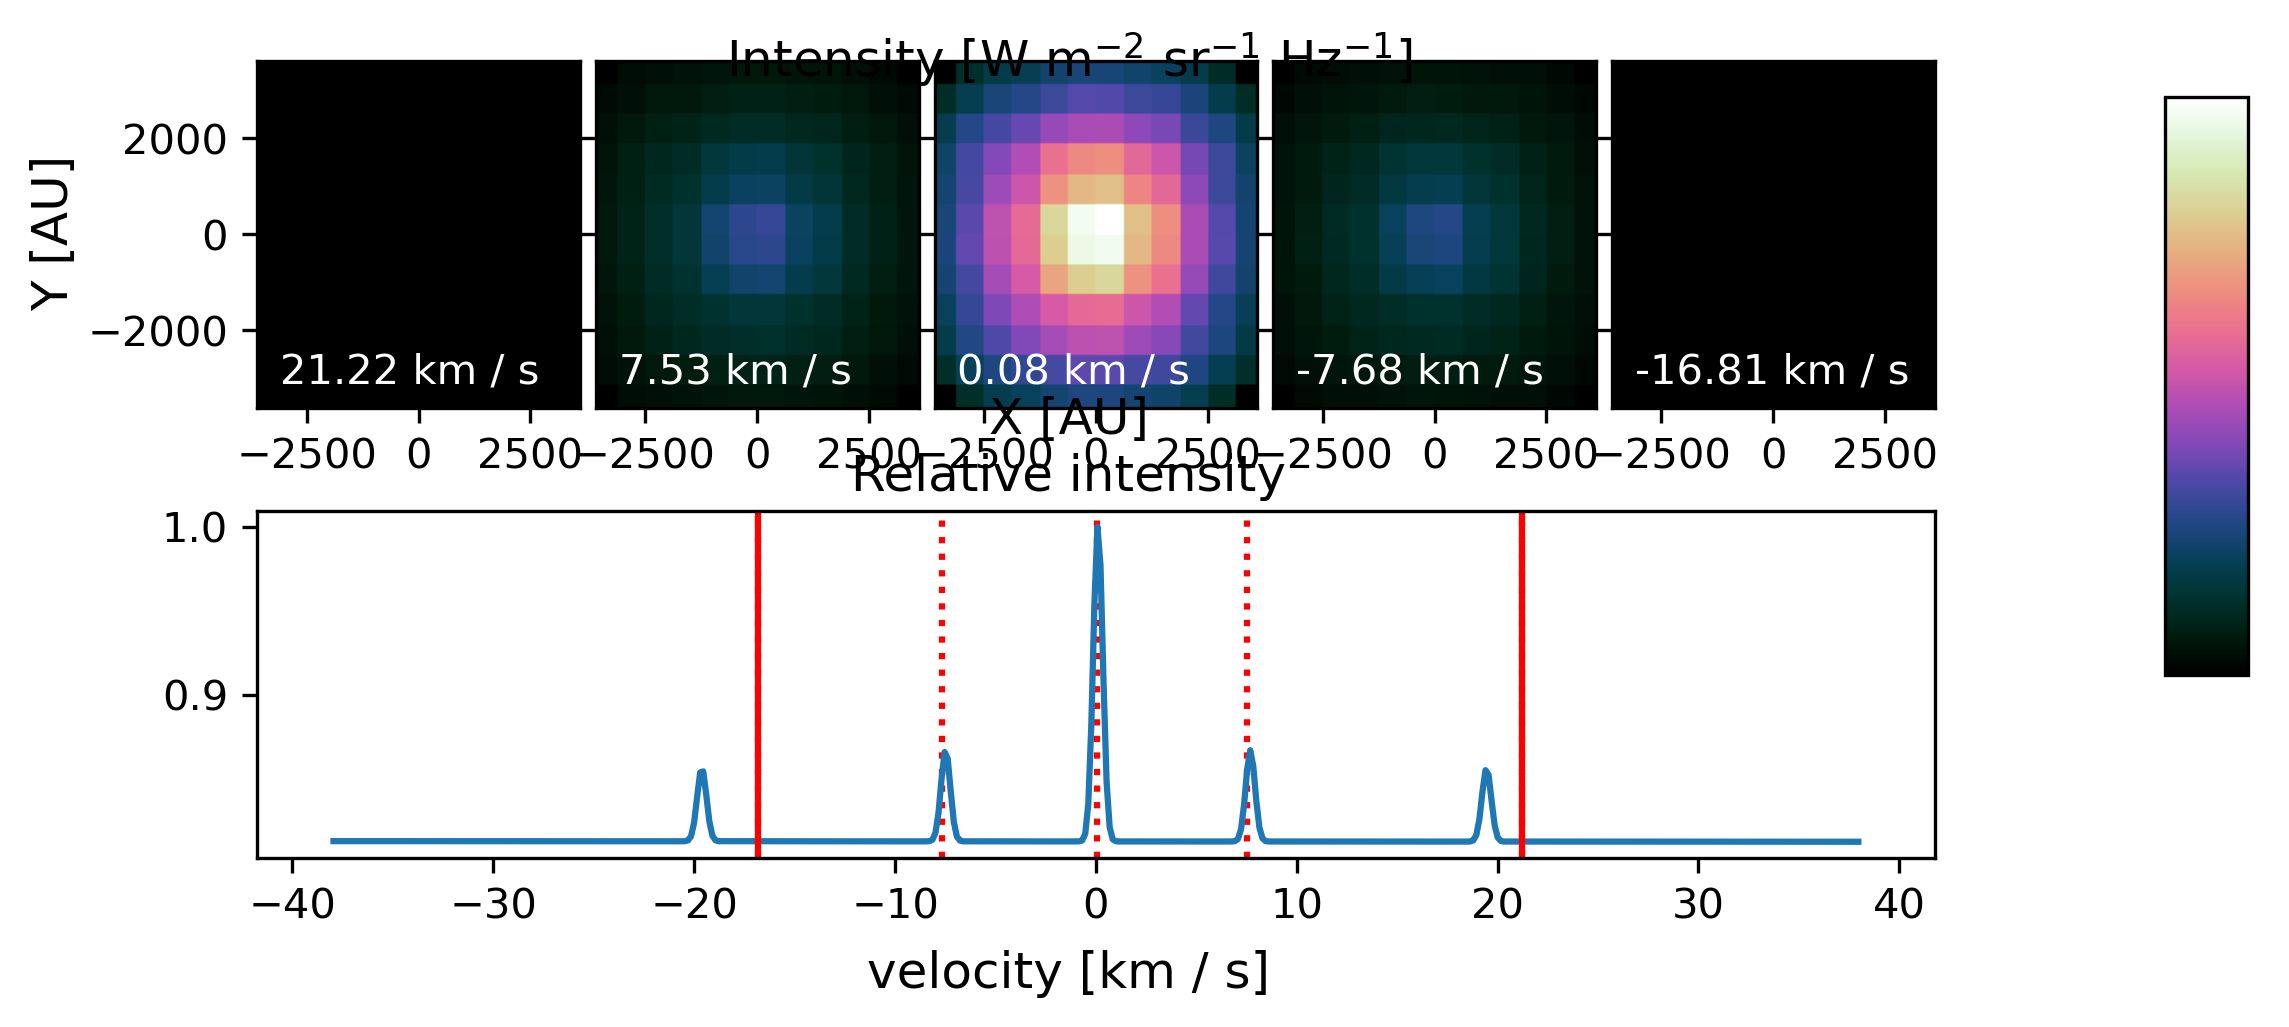

In [ ]:
# plot.image_channel(model,[3243,3244],[1,2])
fig=plot.image_channel(model,[110,200,249,300,360],[1,5])

In [ ]:
#frequencies and intensities can be extracted from the image object
velos = (np.array(model.images[-1].freqs) - fcen)/fcen*3e8/1000 #convert frequency to velocity in km/s
intensities = np.array(model.images[-1].I)[:,:] #intensities [pixel index, frequency index]
print(intensities.shape) #(nrays, nfreqs)
#see ImX, ImY in model.images[-1] for the pixel coordinates; will need to be multiplied with the (unit) direction vectors: image_direction_x, image_direction_y
pixel_coords_x, pixel_coords_y = np.array(model.images[-1].ImX), np.array(model.images[-1].ImY)

# Is = np.sum(intensities, axis=0) * (np.max(pixel_coords_x) - np.min(pixel_coords_x)) * (np.max(pixel_coords_y) - np.min(pixel_coords_y)) / (len(pixel_coords_x))
Is=(intensities[119,:]+intensities[120,:]+intensities[135,:]+intensities[136,:])/4

# I assume you want the intensity, integrated over the image area; NOTE: the normalization still needed to be done, so multiply with the area of a single pixel = total area [in m2]/number of pixels
# the resulting intensity (Is) should be in units of [W sr-1 Hz-1]; though any other normalization still has to be done
# print(velos,Is)
# len(velos), len(Is)
# print(max(Is))

(256, 500)


In [ ]:
print(velos,Is)
np.size(velos), np.size(Is)
print(np.max(Is))

[-37.98350657 -37.83126806 -37.67902956 -37.52679106 -37.37455256
 -37.22231405 -37.07007555 -36.91783705 -36.76559854 -36.61336004
 -36.46112154 -36.30888303 -36.15664453 -36.00440603 -35.85216752
 -35.69992902 -35.54769052 -35.39545201 -35.24321351 -35.09097501
 -34.9387365  -34.786498   -34.6342595  -34.48202099 -34.32978249
 -34.17754399 -34.02530548 -33.87306698 -33.72082848 -33.56858997
 -33.41635147 -33.26411297 -33.11187446 -32.95963596 -32.80739746
 -32.65515895 -32.50292045 -32.35068195 -32.19844344 -32.04620494
 -31.89396644 -31.74172793 -31.58948943 -31.43725093 -31.28501242
 -31.13277392 -30.98053542 -30.82829691 -30.67605841 -30.52381991
 -30.3715814  -30.2193429  -30.0671044  -29.91486589 -29.76262739
 -29.61038889 -29.45815038 -29.30591188 -29.15367338 -29.00143487
 -28.84919637 -28.69695787 -28.54471936 -28.39248086 -28.24024236
 -28.08800386 -27.93576535 -27.78352685 -27.63128835 -27.47904984
 -27.32681134 -27.17457284 -27.02233433 -26.87009583 -26.71785733
 -26.56561

500
500


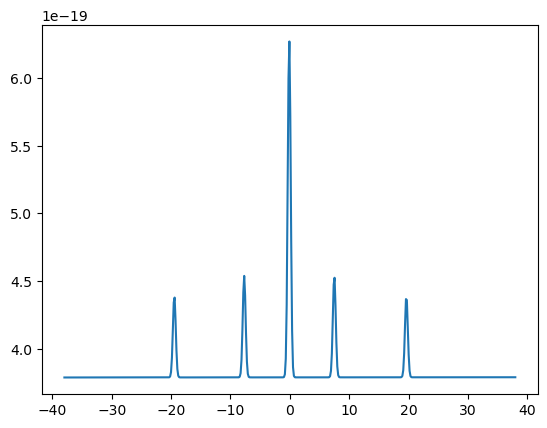

In [ ]:
velos1=velos
import matplotlib.pyplot as plt
plt.plot(velos1, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits
hdu = fits.PrimaryHDU(Is/np.max(Is))
print(len(velos1))
hdu.header['CRVAL1'] = velos1[0]
hdu.header['CDELT1'] = velos1[1] - velos1[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos1)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel

fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_oneone_normalised.fits')
hdu.writeto(fits_file, overwrite=True)

hdu = fits.PrimaryHDU(Is)
print(len(velos1))
hdu.header['CRVAL1'] = velos1[0]
hdu.header['CDELT1'] = velos1[1] - velos1[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos1)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel

fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_oneone_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)


Computing spectral discretisation...
Computing image new...
length: 65


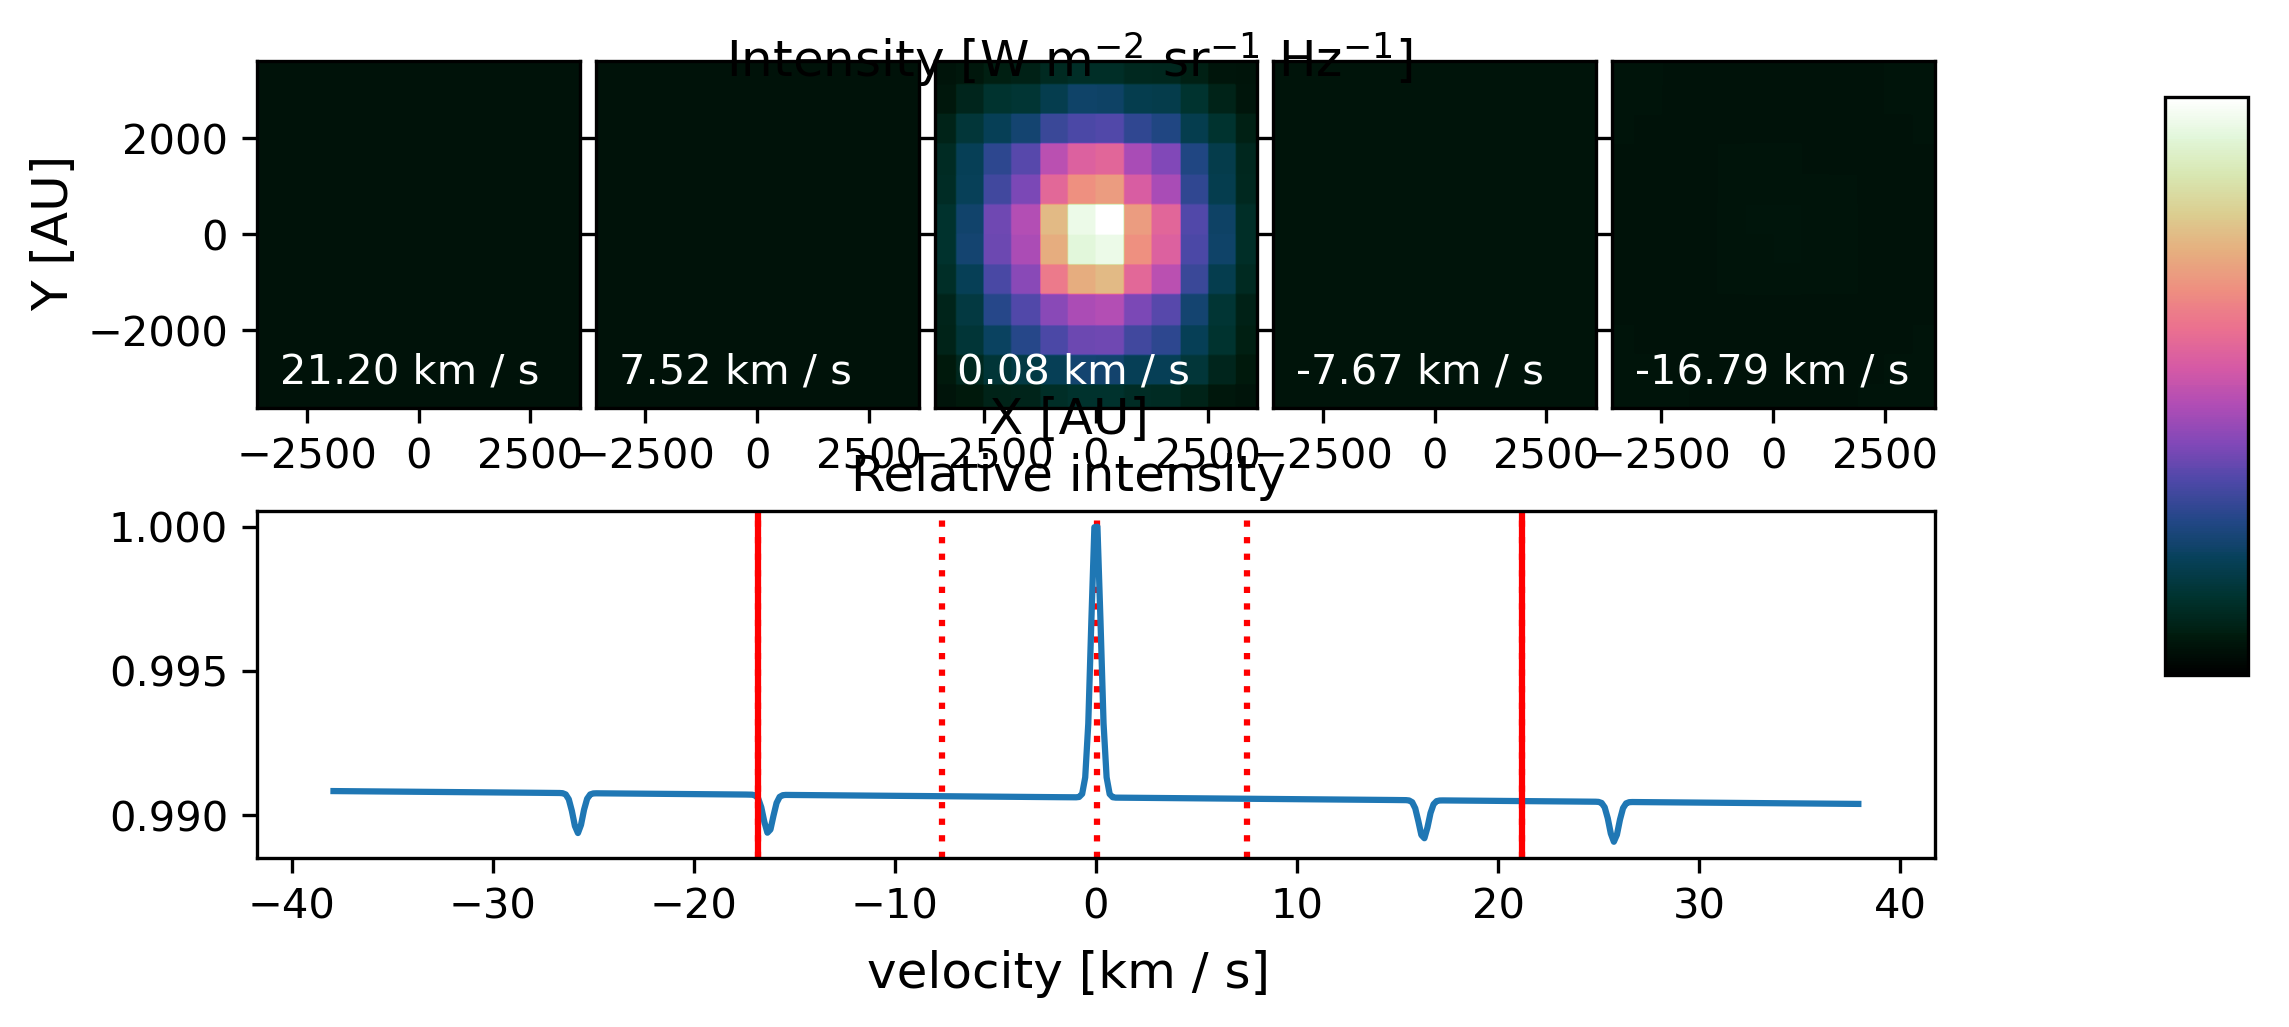

In [ ]:

fcen = model.lines.lineProducingSpecies[0].linedata.frequency[6]
fmin=fcen- 3000000.00
fmax=fcen+ 3000000.00
# Ray orthogonal to image plane
ray_nr = 0

model.compute_spectral_discretisation (fmin, fmax,500)#bins the frequency spectrum [fmin, fmax] into model.parameters.nfreqs bins.
# model.compute_spectral_discretisation (fmin, fmax, 31)#bins using the specified amount of frequency bins (31). Can be any integer >=1

model.compute_image_new               (ray_nr, 16, 16)#using a resolution of 512x512 for the image. 
#Instead of definining a ray index [0, nrays-1], you can also define a ray direction for the imager 

fig=plot.image_channel(model,[110,200,249,300,360],[1,5])

In [ ]:
#frequencies and intensities can be extracted from the image object
velos = (np.array(model.images[-1].freqs) - fcen)/fcen*3e8/1000 #convert frequency to velocity in km/s
intensities = np.array(model.images[-1].I)[:,:] #intensities [pixel index, frequency index]
print(intensities.shape) #(nrays, nfreqs)
#see ImX, ImY in model.images[-1] for the pixel coordinates; will need to be multiplied with the (unit) direction vectors: image_direction_x, image_direction_y
pixel_coords_x, pixel_coords_y = np.array(model.images[-1].ImX), np.array(model.images[-1].ImY)
# Is = np.sum(intensities, axis=0) * (np.max(pixel_coords_x) - np.min(pixel_coords_x)) * (np.max(pixel_coords_y) - np.min(pixel_coords_y)) / (len(pixel_coords_x))
Is=(intensities[119,:]+intensities[120,:]+intensities[135,:]+intensities[136,:])/4


(256, 500)


[-37.93844647 -37.78638857 -37.63433067 -37.48227276 -37.33021486
 -37.17815696 -37.02609906 -36.87404116 -36.72198326 -36.56992535
 -36.41786745 -36.26580955 -36.11375165 -35.96169375 -35.80963585
 -35.65757794 -35.50552004 -35.35346214 -35.20140424 -35.04934634
 -34.89728844 -34.74523053 -34.59317263 -34.44111473 -34.28905683
 -34.13699893 -33.98494103 -33.83288312 -33.68082522 -33.52876732
 -33.37670942 -33.22465152 -33.07259362 -32.92053571 -32.76847781
 -32.61641991 -32.46436201 -32.31230411 -32.16024621 -32.0081883
 -31.8561304  -31.7040725  -31.5520146  -31.3999567  -31.2478988
 -31.09584089 -30.94378299 -30.79172509 -30.63966719 -30.48760929
 -30.33555139 -30.18349348 -30.03143558 -29.87937768 -29.72731978
 -29.57526188 -29.42320397 -29.27114607 -29.11908817 -28.96703027
 -28.81497237 -28.66291447 -28.51085656 -28.35879866 -28.20674076
 -28.05468286 -27.90262496 -27.75056706 -27.59850915 -27.44645125
 -27.29439335 -27.14233545 -26.99027755 -26.83821965 -26.68616174
 -26.5341038

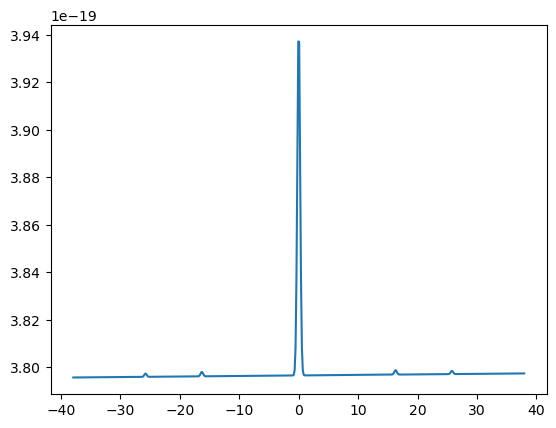

In [ ]:
velos2=velos
print(velos2)
#shift velo to have the centre at 0
plt.plot(velos2, Is)

# Save the image to a FITS file conforming to radio 1D format
import astropy.io.fits as fits
hdu = fits.PrimaryHDU(Is/np.max(Is))

hdu.header['CRVAL1'] = velos2[0]
hdu.header['CDELT1'] = velos2[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_normalised.fits')
hdu.writeto(fits_file, overwrite=True)

hdu = fits.PrimaryHDU(Is)

hdu.header['CRVAL1'] = velos2[0]
hdu.header['CDELT1'] = velos2[1] - velos2[0]
hdu.header['CTYPE1'] = 'VELO-LSR'
hdu.header['CUNIT1'] = 'km/s'
hdu.header['NAXIS1'] = len(velos2)
hdu.header['RESTFREQ'] = fcen  # Rest frequency of the line
hdu.header['CRPIX1'] = 1  # FITS convention for first pixel
fits_file = os.path.join(wdir, 'simulated_nh3_spectrum_twotwo_unnormalised.fits')
hdu.writeto(fits_file, overwrite=True)

#### Code to simultaneously fit the one-one and two-two lines using an ammonia hyperfine model

INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,500 [pyspeckit.spectrum.interactive]
RMS guess (errspec):  1.0
RMS guess (residuals):  6.879210657636598e-05
INFO: Creating spectra [pyspeckit.spectrum.classes]
INFO: Concatenating data [pyspeckit.spectrum.classes]
INFO: Left region selection unchanged.  xminpix, xmaxpix: 0,1000 [pyspeckit.spectrum.interactive]
Iter       1    CHI-SQUARE =  1.706845634e+11  DOF =  988
   trot0 = 5.65  
   tex0 = 4.49  
   ntot0 = 15.5  
   width0 = 0.2352819336  
   xoff_v0 = -0.0002993723358  
   fortho0 = 0.3  
   trot1 = 5.699540298  
   tex1 = 4.49  
   ntot1 = 16.06467187  
   width1 = 1.130392284  
   xoff_v1 = 0.2918363746  
   fortho1 = 0.3  
Iter       2    CHI-SQUARE =  9.03557133e+10  DOF =  988
   trot0 = 5.650057749  
   tex0 = 4.489745849  
   ntot0 = 15.93425581  
   width0 = 0.2352830318  
   xoff_v0 = -0.0002993522072  
   fortho0 = 1  
   trot1 = 5.6995387  
   tex1 = 4.489726363  
   ntot1 = 16.08307941  
   width1 = 1.13039

Iter      44    CHI-SQUARE =  7121154.133  DOF =  988
   trot0 = 10.92081618  
   tex0 = 34.62755541  
   ntot0 = 15.8887864  
   width0 = 0.1989145161  
   xoff_v0 = -0.05851704335  
   fortho0 = 0.9990271111  
   trot1 = 5.947025982  
   tex1 = 3.296524002  
   ntot1 = 16.23793675  
   width1 = 1.100990055  
   xoff_v1 = 0.2900031837  
   fortho1 = 1  
Iter      45    CHI-SQUARE =  7120309.721  DOF =  988
   trot0 = 10.92111151  
   tex0 = 35.62755541  
   ntot0 = 15.88776313  
   width0 = 0.198918736  
   xoff_v0 = -0.058500631  
   fortho0 = 0.9990272738  
   trot1 = 5.947025982  
   tex1 = 3.296524002  
   ntot1 = 16.23793675  
   width1 = 1.100990055  
   xoff_v1 = 0.2900031837  
   fortho1 = 1  
Iter      46    CHI-SQUARE =  7119491.437  DOF =  988
   trot0 = 10.92142602  
   tex0 = 36.62755541  
   ntot0 = 15.88659364  
   width0 = 0.1989246029  
   xoff_v0 = -0.0582169918  
   fortho0 = 0.9990269738  
   trot1 = 5.947025982  
   tex1 = 3.296524002  
   ntot1 = 16.23793675  
  

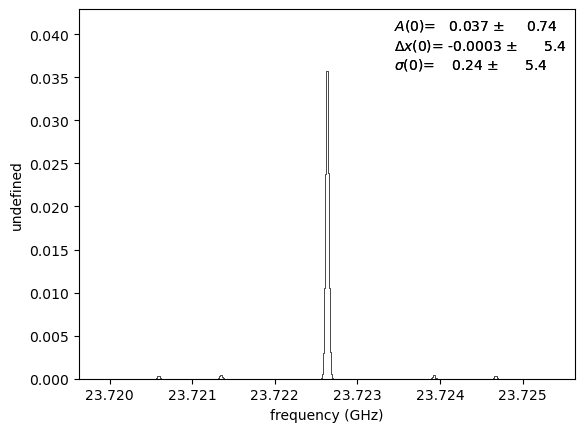

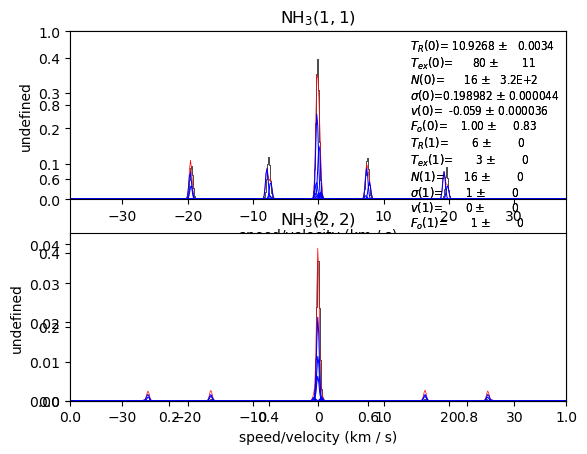

In [ ]:
import pyspeckit

# The ammonia fitting wrapper requires a dictionary specifying the transition name
# (one of the four specified below) and the filename.  Alternately, you can have the
# dictionary values be pre-loaded Spectrum instances
filenames = {'oneone':'/home/yasho379/magritte_rebuilt/tgs/simulated_nh3_spectrum_oneone_normalised.fits',
    'twotwo':'/home/yasho379/magritte_rebuilt/tgs/simulated_nh3_spectrum_twotwo_normalised.fits'}

# Fit the ammonia spectrum with some reasonable initial guesses.  It is
# important to crop out extraneous junk and to smooth the data to make the
# fit proceed at a reasonable pace.
spdict1,spectra1 = pyspeckit.wrappers.fitnh3.fitnh3tkin(filenames,crop=False,npeaks=2,guessline='twotwo',rebase=True,tkin=5.65,tex=4.49,column=15.5,fortho=0.3,verbose=True, smooth=False,dobaseline=True,doplot=True,fittype='ammonia')


#### Code to convert from Spectral Radiance to Main beam temperature

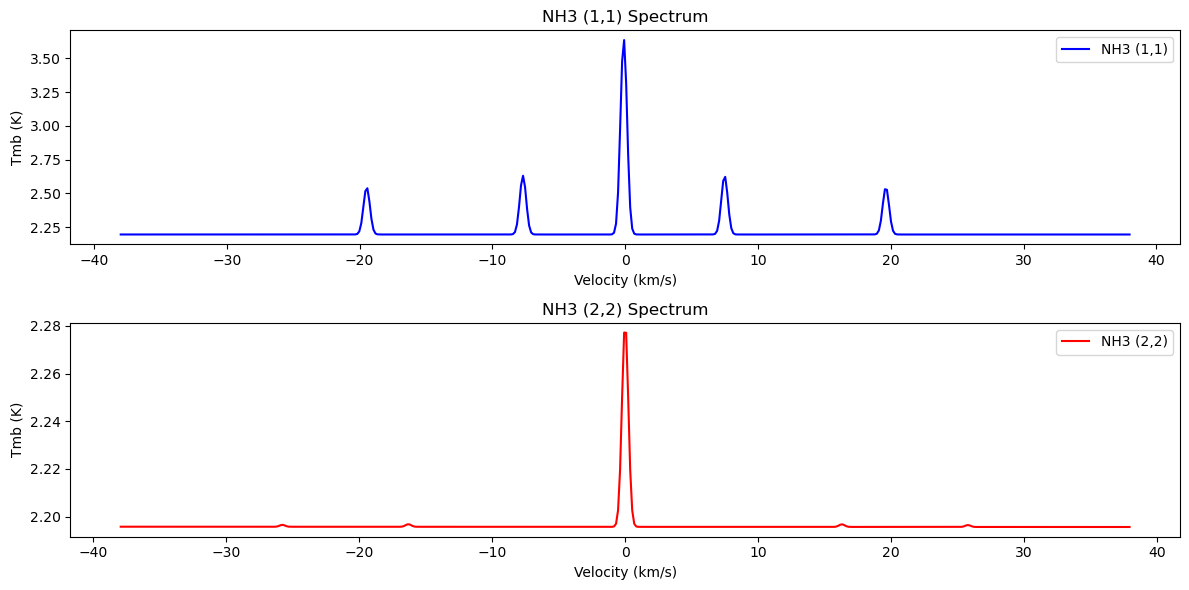

In [ ]:

from astropy import units as u
import astropy.io.fits as fits
import numpy as np

h  = 6.62607015e-34          # Planck  [J s]
k_B  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]

filenames = {'oneone':'/home/yasho379/magritte_rebuilt/tgs/simulated_nh3_spectrum_oneone_unnormalised.fits',
    'twotwo':'/home/yasho379/magritte_rebuilt/tgs/simulated_nh3_spectrum_twotwo_unnormalised.fits'}

# Load the spectra from the FITS files
spec1 = fits.getdata(filenames['oneone'])
spec2 = fits.getdata(filenames['twotwo'])

# Get velocity axes from FITS headers
with fits.open(filenames['oneone']) as hdul:
    hdr1 = hdul[0].header
    velos1 = hdr1['CRVAL1'] + np.arange(hdr1['NAXIS1']) * hdr1['CDELT1']

with fits.open(filenames['twotwo']) as hdul:
    hdr2 = hdul[0].header
    velos2 = hdr2['CRVAL1'] + np.arange(hdr2['NAXIS1']) * hdr2['CDELT1']

# Get rest frequencies from headers
freq1 = hdr1['RESTFREQ'] 
freq2 = hdr2['RESTFREQ']

# Convert intensity (assumed in W/(m^2 Hz sr)) to main beam temperature (K)
def intensity_to_Tmb(v,I, freq):
    Tmb = (c**2 * I) / (2 * k_B * (freq*(1+v/c))**2)
    return Tmb

Tmb1 = intensity_to_Tmb(1000*velos1,spec1, freq1)
Tmb2 = intensity_to_Tmb(1000*velos2,spec2, freq2)
# now plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(velos1, Tmb1, label='NH3 (1,1)', color='blue')
plt.title('NH3 (1,1) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(velos2, Tmb2, label='NH3 (2,2)', color='red')
plt.title('NH3 (2,2) Spectrum')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.tight_layout()
plt.show()



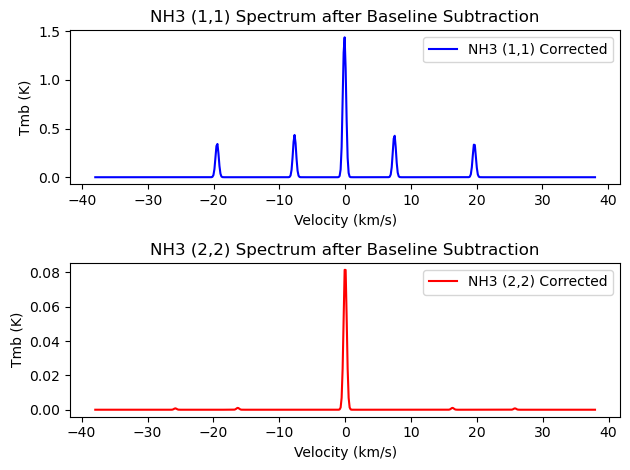

In [ ]:
#subtract baseline from the spectra by subtracting a straight line fitted to the edges of the spectra
from scipy.signal import savgol_filter
def subtract_baseline(velos, intensities, edge_fraction=0.1):
    n = len(velos)
    edge_n = int(n * edge_fraction)
    
    # Select edge points
    edge_velos = np.concatenate((velos[:edge_n], velos[-edge_n:]))
    edge_intensities = np.concatenate((intensities[:edge_n], intensities[-edge_n:]))
    
    # Fit a linear baseline to the edge points
    coeffs = np.polyfit(edge_velos, edge_intensities, 1)
    baseline = np.polyval(coeffs, velos)
    
    # Subtract the baseline from the original intensities
    corrected_intensities = intensities - baseline
    
    return corrected_intensities
Tmb1_corrected = subtract_baseline(velos1, Tmb1)
Tmb2_corrected = subtract_baseline(velos2, Tmb2)
plt.subplot(2, 1, 1)
plt.plot(velos1, Tmb1_corrected, label='NH3 (1,1) Corrected', color='blue')
plt.title('NH3 (1,1) Spectrum after Baseline Subtraction')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(velos2, Tmb2_corrected, label='NH3 (2,2) Corrected', color='red')
plt.title('NH3 (2,2) Spectrum after Baseline Subtraction')
plt.xlabel('Velocity (km/s)')
plt.ylabel('Tmb (K)')
plt.legend()
plt.tight_layout()
plt.show()

Initial guess: [np.float64(2.1963249345588283), np.float64(1.6389671038010015e-06), np.float64(1.211570318816633), np.float64(-19.067872536495255), np.float64(1.8991753283311712), np.float64(1.211570318816633), np.float64(-9.571995894839398), np.float64(1.8991753283311712), np.float64(1.211570318816633), np.float64(-0.07611925318354196), np.float64(1.8991753283311712), np.float64(1.211570318816633), np.float64(9.419757388472316), np.float64(1.8991753283311712), np.float64(1.211570318816633), np.float64(18.91563403012817), np.float64(1.8991753283311712)]
Lower bounds: [np.float64(2.1962626808410786), -inf, 0.001, -inf, 1e-06, 0.001, -inf, 1e-06, 0.001, -inf, 1e-06, 0.001, -inf, 1e-06, 0.001, -inf, 1e-06]
Upper bounds: [np.float64(3.634710956449899), inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf]
Initial guess: [np.float64(2.1957431164125505), np.float64(1.646142419051993e-06), np.float64(0.7590573598672946), np.float64(-23.787557994558274), np.float64(1.

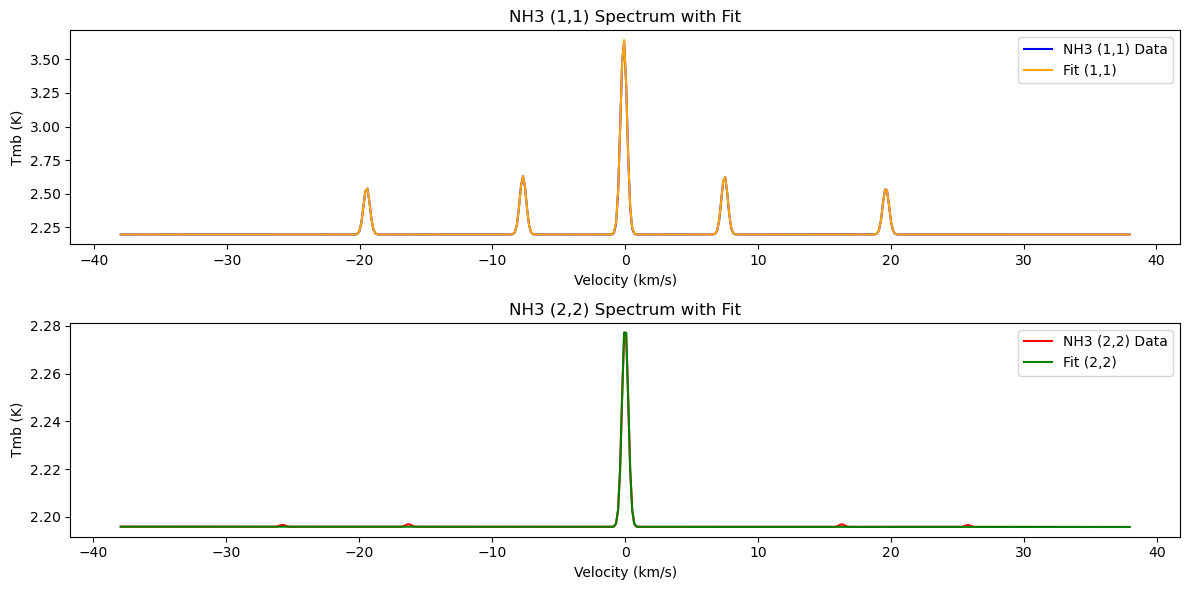

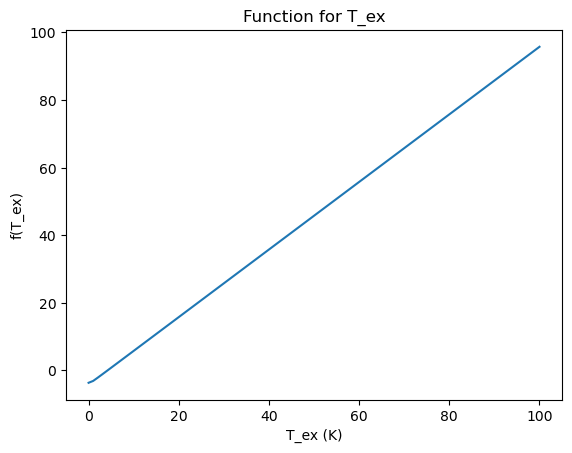

∫Tmb dv (1,1): 1.842 K km/s
∫Tmb dv (2,2): 0.052 K km/s
τ(1,1)       : 9.18
T_ex (1,1)   : 4.20 K
T_rot        : 10.19 K
T_kin        : 10.73 K


In [ ]:

"""
NH3 (1,1) and (2,2) line analysis: Gaussian fitting, τ, T_ex, T_rot
"""
import numpy as np
from scipy.optimize import curve_fit, brentq

# --------------------------- constants ---------------------------
h  = 6.62607015e-34          # Planck  [J s]
k  = 1.380649e-23            # Boltzmann [J K⁻¹]
c  = 2.99792458e8            # speed of light [m s⁻¹]
T_BG  = 2.73                 # CMB [K]
NU_11 = 23.6944955e9         # NH3 (1,1) [Hz]
NU_22 = 23.7226333e9         # NH3 (2,2) [Hz]
DELTA_E_K = 42.32            # (2,2)–(1,1) energy gap [K]

# --------------------------- models ---------------------------
def gaussian(v, amp, cen, sig):
    """Single Gaussian."""
    return amp * np.exp(-0.5 * ((v - cen)/sig)**2)

def multi_gaussian(v,*pars):
    """Sum of N Gaussians; pars = [amp1,cen1,sig1, …, ampN,cenN,sigN]."""
    n = len(pars)//3
    out = np.zeros_like(v)
    for i in range(n):
        a, c, s = pars[2+3*i :2+3*i+3]
        out += gaussian(v, a, c, s)
    return out + pars[0] + pars[1] * v  # offset + slope

# --------------------------- fitting ---------------------------
def fit_five_gaussians(v, tmb, number, p0=None):
    """Fit 5 Gaussians; returns best-fit parameters (len=15) with positive amplitudes."""
    if p0 is None:  # crude automatic seed
        idx_max = np.argmax(tmb)
        vpk, amp_pk = v[idx_max], tmb[idx_max]
        width = (v[-1] - v[-0]) / 40
        if number == 'one':
            centres = np.linspace(vpk-10*width, vpk+10*width, 5)
        else:
            centres = np.linspace(vpk-12.5*width, vpk+12.5*width, 5)
        p0 = [(tmb[0]+tmb[-1])/2, (tmb[-1]-tmb[0])/(v[0]-v[-1])]  # guess for offset and slope
        for c in centres:
            p0 += [max(amp_pk/3, 1e-3), c, width]  # ensure positive initial amplitude
            # Set bounds: offset free, amplitudes >=0, widths > 0, centers free
            lower_bounds = [min(tmb), -np.inf]
            for i in range(15):
                if i % 3 == 0:      # amplitude
                    lower_bounds.append(0.001)
                elif i % 3 == 2:    # width (sigma)
                    lower_bounds.append(1e-6)
                else:               # center
                    lower_bounds.append(-np.inf)

            upper_bounds = [max(tmb)] + [np.inf] * 16
    print("Initial guess:", p0)
    print("Lower bounds:", lower_bounds)
    print("Upper bounds:", upper_bounds)
    for i in range(len(p0)):
        if p0[i] < lower_bounds[i] or p0[i] > upper_bounds[i]:
            raise ValueError(f"Initial guess p0[{i}]={p0[i]} is out of bounds [{lower_bounds[i]}, {upper_bounds[i]}]")  

    pars, _ = curve_fit(
        lambda vv, *pp: multi_gaussian(vv, *pp),
        v, tmb, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=200000
    )
    return pars

def comp_areas(pars):
    """Return arrays of areas (K km/s) for each Gaussian component."""
    amps  = pars[2::3]
    sigs  = pars[4::3]
    return amps * sigs * np.sqrt(2*np.pi)

# ------------------------ line diagnostics -----------------------
def J_nu(T, nu):
    return (h*nu/k) / (np.exp(h*nu/(k*T)) - 1)

def tau_from_sat(Ts, Tm, a_s=0.22):
    """Solve τ from T_s/T_m ratio (inner satellite)."""
    f = lambda tau: (1 - np.exp(-a_s*tau))/(1 - np.exp(-tau)) - Ts/Tm
    return brentq(f, 1e-4, 100)

def tex_from_tau(Tmb_peak, tau, nu, method= 'brentq'):
    if method == 'brentq':
        """Solve T_ex from radiative-transfer equation."""
        Jbg = J_nu(T_BG, nu)
        f = lambda Tex: (J_nu(Tex, nu) - Jbg)*(1 - np.exp(-tau)) - Tmb_peak
        #plot f at a range of values
        import matplotlib.pyplot as plt
        Tex_vals = np.linspace(0, 100, 100)
        plt.plot(Tex_vals, f(Tex_vals), label='f(Tex)')
        plt.xlabel('T_ex (K)')
        plt.ylabel('f(T_ex)')
        plt.title('Function for T_ex')
        plt.show()
        return brentq(f, 1e-4, 100)
    elif method == 'simple':
        return Tmb_peak/(1-np.exp(-tau)) + T_BG

def T_rot(int11, int22):
    ratio = (int11/int22) * (9/5)          # statistical weight factor
    return DELTA_E_K / np.log(ratio)

# ------------------------------- main ---------------------------
def analyse_pair(v11, t11, v22, t22,
                 main_idx11=2, sat_idx11=1, a_s=0.22):
    # ----- fit spectra
    p11 = fit_five_gaussians(v11, t11,'one')
    p22 = fit_five_gaussians(v22, t22,'two')
    print(p11)
    print(p22)
    #plot the fitted spectra
    amps11  = p11[2::3]; cents11=p11[3::3];  sigs11 = p11[4::3]*1000
    amps22  = p22[2::3]; cents22=p22[3::3];  sigs22 = p22[4::3]*1000

    #plot the fitted spectra
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(v11, t11, label='NH3 (1,1) Data', color='blue')
    plt.plot(v11, multi_gaussian(v11, *p11), label='Fit (1,1)', color='orange')
    plt.title('NH3 (1,1) Spectrum with Fit')
    plt.xlabel('Velocity (km/s)')
    plt.ylabel('Tmb (K)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(v22, t22, label='NH3 (2,2) Data', color='red')
    plt.plot(v22, multi_gaussian(v22, *p22), label='Fit (2,2)', color='green')
    plt.title('NH3 (2,2) Spectrum with Fit')
    plt.xlabel('Velocity (km/s)')
    plt.ylabel('Tmb (K)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ----- integrated intensities (K km/s)
    I11 = np.sum(comp_areas(p11))
    I22 = np.sum(comp_areas(p22))

    # ----- optical depth via satellite ratio
    tau_11 = tau_from_sat(amps11[sat_idx11], amps11[main_idx11], a_s)

    # ----- excitation temperature
    Tex_11 = tex_from_tau(amps11[main_idx11], tau_11, NU_11, method='brentq')

    # ----- rotational temperature
    Trot = T_rot(I11, I22)

    # ----- kinetic temperature
    Tkin = Trot /(1-(Trot/42)*np.log(1+1.1*np.exp(-16/Trot)))

    return dict(I11=I11, I22=I22, tau_11=tau_11, Tex_11=Tex_11,
                Trot=Trot, Tkin=Tkin, fit_params_11=p11, fit_params_22=p22)

res = analyse_pair(velos1, Tmb1, velos2, Tmb2,
                       main_idx11=2,
                       sat_idx11=4,
                       a_s=0.03)

print(f"∫Tmb dv (1,1): {res['I11']:.3f} K km/s")
print(f"∫Tmb dv (2,2): {res['I22']:.3f} K km/s")
print(f"τ(1,1)       : {res['tau_11']:.2f}")
print(f"T_ex (1,1)   : {res['Tex_11']:.2f} K")
print(f"T_rot        : {res['Trot']:.2f} K")
print(f"T_kin        : {res['Tkin']:.2f} K")